# Assignment 8: GPU Accelerated Machine Learning
> **Runtime → Change runtime type → T4 GPU** before running.

This notebook translates all 5 `.cu` exercises into PyCUDA / PyTorch.
Each section follows the exact same Section A / B / C structure as the original scripts.

---

In [1]:
!pip install pycuda -q
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time, math
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
print('PyCUDA ready | PyTorch', torch.__version__, '| CUDA', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.1 MB/s eta 0:00:00
PyCUDA ready | PyTorch 2.10.0+cu128 | CUDA 12.8
GPU: Tesla T4


---
## Exercise 1 — CUDA Basics (ex01_cuda_basics.cu)
### Section A — Reference: Vector Addition

In [2]:
# ── Section A1: vectorAdd (provided reference) ───────────────────────────────
mod_ex01 = SourceModule("""
/* ---- A1: provided ---- */
__global__ void vectorAdd(const float* A, const float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

/* ---- B1: vectorScale  C[i] = k * A[i] ---- */
__global__ void vectorScale(const float* A, float* C, float k, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = k * A[i];   // TODO B1 filled
}

/* ---- B2: squaredDiff  C[i] = (A[i]-B[i])^2 ---- */
__global__ void squaredDiff(const float* A, const float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) { float d = A[i]-B[i]; C[i] = d*d; }  // TODO B2 filled
}

/* ---- C1: ReLU ---- */
__global__ void reluKernel(const float* x, float* out, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) out[i] = fmaxf(0.0f, x[i]);
}

/* ---- C2: warp divergence vs branch-free ---- */
__global__ void divergentKernel(float* data, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        if (threadIdx.x % 2 == 0) data[i] = data[i] * 2.0f;
        else                      data[i] = data[i] + 1.0f;
    }
}
__global__ void branchFreeKernel(float* data, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        int even = (threadIdx.x % 2 == 0);
        data[i] = even * (data[i] * 2.0f) + (1-even) * (data[i] + 1.0f);
    }
}
""")

vecAdd     = mod_ex01.get_function('vectorAdd')
vecScale   = mod_ex01.get_function('vectorScale')
sqDiff     = mod_ex01.get_function('squaredDiff')
reluKern   = mod_ex01.get_function('reluKernel')
divKern    = mod_ex01.get_function('divergentKernel')
bfKern     = mod_ex01.get_function('branchFreeKernel')
print('Ex01 kernels compiled')

Ex01 kernels compiled


In [3]:
def gpu_run(kern, *args, N, threads=256):
    blocks = (N + threads - 1) // threads
    s = cuda.Event(); e = cuda.Event()
    s.record()
    kern(*args, np.int32(N), block=(threads,1,1), grid=(blocks,1))
    e.record(); e.synchronize()
    return s.time_till(e)

N = 1 << 20
h_A = np.random.rand(N).astype(np.float32)
h_B = np.random.rand(N).astype(np.float32)
h_C = np.zeros(N, np.float32)

d_A = cuda.mem_alloc(h_A.nbytes); d_B = cuda.mem_alloc(h_B.nbytes)
d_C = cuda.mem_alloc(h_C.nbytes)
cuda.memcpy_htod(d_A, h_A); cuda.memcpy_htod(d_B, h_B)

t0 = time.perf_counter()
cpu_ref = h_A + h_B
cpu_ms = (time.perf_counter() - t0) * 1000

gpu_ms = gpu_run(vecAdd, d_A, d_B, d_C, N=N)
cuda.memcpy_dtoh(h_C, d_C)

print(f'[A1-VectorAdd] N={N:,}  CPU={cpu_ms:.1f}ms  GPU={gpu_ms:.3f}ms  '
      f'Speedup={cpu_ms/gpu_ms:.1f}x  PASS={np.allclose(h_C, cpu_ref, atol=1e-4)}')

[A1-VectorAdd] N=1,048,576  CPU=2.2ms  GPU=0.751ms  Speedup=2.9x  PASS=True


### Section B — DIY Kernels

In [4]:
# B1: vectorScale
k = np.float32(3.14)
d_C2 = cuda.mem_alloc(h_A.nbytes)
gpu_run(vecScale, d_A, d_C2, k, N=N)
h_C2 = np.empty_like(h_A); cuda.memcpy_dtoh(h_C2, d_C2)
print(f'[B1-VectorScale] k={k:.2f}  PASS={np.allclose(h_C2, k*h_A, atol=1e-4)}')

# B2: squaredDiff
d_C3 = cuda.mem_alloc(h_A.nbytes)
gpu_run(sqDiff, d_A, d_B, d_C3, N=N)
h_C3 = np.empty_like(h_A); cuda.memcpy_dtoh(h_C3, d_C3)
ref_sq = (h_A - h_B)**2
print(f'[B2-SquaredDiff]  PASS={np.allclose(h_C3, ref_sq, atol=1e-4)}')

[B1-VectorScale] k=3.14  PASS=True
[B2-SquaredDiff]  PASS=True


In [7]:
# B3: Launch configuration table
N_lc = 1 << 20
print(f'\n[B3-LaunchConfig] N = {N_lc:,}')
print(f'{"threads/block":>15} {"blocks":>10} {"total threads":>15} {"covers N?":>10} {"time (ms)":>12}')
d_tmp = cuda.mem_alloc(N_lc * 4)
cuda.memcpy_htod(d_tmp, h_A)
d_tmp2 = cuda.mem_alloc(N_lc * 4)
d_tmp = cuda.mem_alloc(N_lc * 4)
cuda.memcpy_htod(d_tmp, h_A)
d_tmp2 = cuda.mem_alloc(N_lc * 4)

for tpb in [64, 128, 256, 512, 1024]:
    blks = (N_lc + tpb - 1) // tpb
    total = blks * tpb
    covers = total >= N_lc
    s = cuda.Event(); e = cuda.Event()
    s.record()
    vecAdd(d_tmp, d_tmp, d_tmp2, np.int32(N_lc), block=(tpb,1,1), grid=(blks,1))
    e.record(); e.synchronize()
    ms = s.time_till(e)
    print(f'{tpb:>15} {blks:>10} {total:>15} {str(covers):>10} {ms:>12.3f}')
d_tmp.free(); d_tmp2.free()


[B3-LaunchConfig] N = 1,048,576
  threads/block     blocks   total threads  covers N?    time (ms)
             64      16384         1048576       True        0.178
            128       8192         1048576       True        0.064
            256       4096         1048576       True        0.055
            512       2048         1048576       True        0.057
           1024       1024         1048576       True        0.058


In [8]:
# B4: Memory bandwidth benchmark
print('\n[B4-MemoryBandwidth]')
print(f'{"Size (MB)":>10} {"H2D (GB/s)":>12} {"D2H (GB/s)":>12}')
print('-' * 38)

h2d_bws, d2h_bws, sizes_mb = [], [], [1, 8, 64, 256, 512]
for mb in sizes_mb:
    n_bytes = mb * 1024 * 1024
    h_buf = np.ones(n_bytes // 4, dtype=np.float32)
    d_buf = cuda.mem_alloc(n_bytes)

    s = cuda.Event(); e = cuda.Event()
    s.record(); cuda.memcpy_htod(d_buf, h_buf); e.record(); e.synchronize()
    h2d = (mb / 1024.0) / (s.time_till(e) / 1000.0)

    s.record(); cuda.memcpy_dtoh(h_buf, d_buf); e.record(); e.synchronize()
    d2h = (mb / 1024.0) / (s.time_till(e) / 1000.0)

    h2d_bws.append(h2d); d2h_bws.append(d2h)
    print(f'{mb:>10} {h2d:>12.1f} {d2h:>12.1f}')
    d_buf.free()


[B4-MemoryBandwidth]
 Size (MB)   H2D (GB/s)   D2H (GB/s)
--------------------------------------
         1          2.4          2.8
         8          3.5          6.1
        64          4.5          5.5
       256          4.5          4.6
       512          4.3          4.6


In [9]:
# Part A: Bandwidth & Speedup Analysis — sweep over N values
Ns = [1<<10, 1<<14, 1<<18, 1<<22, 1<<26]
cpu_times, gpu_times, h2d_times, speedups = [], [], [], []

for Ni in Ns:
    a = np.random.rand(Ni).astype(np.float32)
    b = np.random.rand(Ni).astype(np.float32)
    da = cuda.mem_alloc(a.nbytes); db = cuda.mem_alloc(b.nbytes)
    dc = cuda.mem_alloc(a.nbytes)

    t0 = time.perf_counter(); _ = a + b; cpu_ms = (time.perf_counter()-t0)*1000

    s=cuda.Event(); e=cuda.Event()
    s.record(); cuda.memcpy_htod(da, a); e.record(); e.synchronize()
    h2d_ms = s.time_till(e)
    cuda.memcpy_htod(db, b)

    blks = (Ni+255)//256
    s.record(); vecAdd(da,db,dc,np.int32(Ni),block=(256,1,1),grid=(blks,1)); e.record(); e.synchronize()
    gpu_ms = s.time_till(e)

    cpu_times.append(cpu_ms); gpu_times.append(gpu_ms)
    h2d_times.append(h2d_ms); speedups.append(cpu_ms/gpu_ms)
    da.free(); db.free(); dc.free()

print(f'{"N":>10} {"CPU(ms)":>10} {"GPU(ms)":>10} {"H2D(ms)":>10} {"Speedup":>10}')
for i,Ni in enumerate(Ns):
    print(f'{Ni:>10} {cpu_times[i]:>10.2f} {gpu_times[i]:>10.3f} {h2d_times[i]:>10.3f} {speedups[i]:>10.2f}x')

         N    CPU(ms)    GPU(ms)    H2D(ms)    Speedup
      1024       0.06      0.089      0.410       0.69x
     16384       0.02      0.036      0.041       0.58x
    262144       0.19      0.016      0.318      11.33x
   4194304       5.46      0.209      3.665      26.16x
  67108864     105.77      3.111     57.304      34.00x


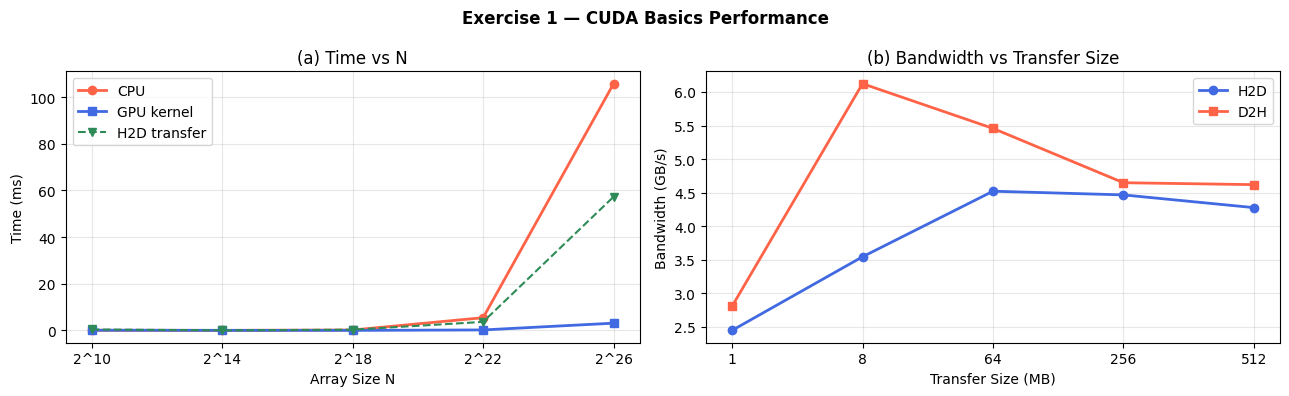

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Exercise 1 — CUDA Basics Performance', fontweight='bold')

labels_n = [f'2^{int(math.log2(n))}' for n in Ns]
axes[0].plot(labels_n, cpu_times, 'o-', label='CPU', color='tomato', linewidth=2)
axes[0].plot(labels_n, gpu_times, 's-', label='GPU kernel', color='royalblue', linewidth=2)
axes[0].plot(labels_n, h2d_times,'v--', label='H2D transfer', color='seagreen', linewidth=1.5)
axes[0].set_xlabel('Array Size N'); axes[0].set_ylabel('Time (ms)')
axes[0].set_title('(a) Time vs N'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([str(s) for s in sizes_mb], h2d_bws, 'o-', label='H2D', color='royalblue', linewidth=2)
axes[1].plot([str(s) for s in sizes_mb], d2h_bws, 's-', label='D2H', color='tomato', linewidth=2)
axes[1].set_xlabel('Transfer Size (MB)'); axes[1].set_ylabel('Bandwidth (GB/s)')
axes[1].set_title('(b) Bandwidth vs Transfer Size'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ex01_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# C1: ReLU stretch
h_x = (np.random.rand(N).astype(np.float32) - 0.5) * 8
d_x = cuda.mem_alloc(h_x.nbytes); d_out = cuda.mem_alloc(h_x.nbytes)
cuda.memcpy_htod(d_x, h_x)
gpu_run(reluKern, d_x, d_out, N=N)
h_out = np.empty_like(h_x); cuda.memcpy_dtoh(h_out, d_out)
print(f'[C1-ReLU-Stretch] PASS={np.allclose(h_out, np.maximum(0, h_x), atol=1e-5)}')
d_x.free(); d_out.free()

# C2: Warp divergence
N_wd = 1 << 18
h_d = np.random.rand(N_wd).astype(np.float32)
d_div = cuda.mem_alloc(h_d.nbytes); d_bf = cuda.mem_alloc(h_d.nbytes)
cuda.memcpy_htod(d_div, h_d); cuda.memcpy_htod(d_bf, h_d)

REPS = 500; blks = (N_wd+255)//256
s=cuda.Event(); e=cuda.Event()
s.record()
for _ in range(REPS): divKern(d_div, np.int32(N_wd), block=(256,1,1), grid=(blks,1))
e.record(); e.synchronize(); div_ms = s.time_till(e)

s.record()
for _ in range(REPS): bfKern(d_bf, np.int32(N_wd), block=(256,1,1), grid=(blks,1))
e.record(); e.synchronize(); bf_ms = s.time_till(e)

print(f'[C2-WarpDivergence] Divergent={div_ms:.2f}ms  BranchFree={bf_ms:.2f}ms  '
      f'Overhead={div_ms/bf_ms:.2f}x')
d_div.free(); d_bf.free()

[C1-ReLU-Stretch] PASS=True
[C2-WarpDivergence] Divergent=5.64ms  BranchFree=4.67ms  Overhead=1.21x


---
## Exercise 2 — Memory Hierarchy (ex02_memory_hierarchy.cu)
### Section A — Provided: Tree Reduction Sum

In [12]:
mod_ex02 = SourceModule("""
/* ---- A2: provided tree reduce sum ---- */
__global__ void treeReduceSum(const float* input, float* output, int N) {
    __shared__ float sdata[256];
    int tid=threadIdx.x, i=blockIdx.x*blockDim.x+tid;
    sdata[tid] = (i<N) ? input[i] : 0.0f;
    __syncthreads();
    for (int s=blockDim.x/2; s>0; s>>=1) {
        if (tid<s) sdata[tid]+=sdata[tid+s];
        __syncthreads();
    }
    if (tid==0) output[blockIdx.x]=sdata[0];
}

/* ---- B1: shared memory copy ---- */
__global__ void smemCopy(const float* input, float* output, int N) {
    __shared__ float tile[256];
    int i = blockIdx.x*blockDim.x + threadIdx.x;
    tile[threadIdx.x] = (i<N) ? input[i] : 0.0f;  // TODO B1-Step1
    __syncthreads();                                // TODO B1-Step2
    if (i<N) output[i] = tile[threadIdx.x];        // TODO B1-Step3
}

/* ---- B2: max reduce ---- */
__global__ void maxReduce(const float* input, float* output, int N) {
    __shared__ float sdata[256];
    int tid=threadIdx.x, i=blockIdx.x*blockDim.x+tid;
    sdata[tid] = (i<N) ? input[i] : -1e30f;   // TODO B2-Step1
    __syncthreads();
    for (int s=blockDim.x/2; s>0; s>>=1) {    // TODO B2-Step2
        if (tid<s) sdata[tid]=fmaxf(sdata[tid],sdata[tid+s]);
        __syncthreads();
    }
    if (tid==0) output[blockIdx.x]=sdata[0];   // TODO B2-Step3
}

/* ---- B4: histogram with atomicAdd ---- */
__global__ void histogram(const int* data, int* hist, int N, int bins) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if (i<N) atomicAdd(&hist[data[i]], 1);  // TODO B4
}

/* ---- C1: warp shuffle reduction ---- */
__global__ void warpSumReduce(const float* data, float* out, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    float val = (i<N) ? data[i] : 0.0f;
    for (int off=16; off>0; off>>=1)
        val += __shfl_down_sync(0xffffffff, val, off);  // STRETCH C1
    if (threadIdx.x%32==0) atomicAdd(out, val);
}

/* ---- C2: shared-memory histogram ---- */
__global__ void histogramSharedMem(const int* data, int* hist, int N, int bins) {
    extern __shared__ int local_hist[];
    for (int b=threadIdx.x; b<bins; b+=blockDim.x) local_hist[b]=0;
    __syncthreads();
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if (i<N) atomicAdd(&local_hist[data[i]], 1);
    __syncthreads();
    for (int b=threadIdx.x; b<bins; b+=blockDim.x) atomicAdd(&hist[b], local_hist[b]);
}
""")

treeSum   = mod_ex02.get_function('treeReduceSum')
smCopy    = mod_ex02.get_function('smemCopy')
maxRed    = mod_ex02.get_function('maxReduce')
histKern  = mod_ex02.get_function('histogram')
warpSum   = mod_ex02.get_function('warpSumReduce')
histSM    = mod_ex02.get_function('histogramSharedMem')
print('Ex02 kernels compiled')

Ex02 kernels compiled


In [13]:
def tree_reduce(kernel, d_data, N, threads=256, identity=0.0):
    blocks = (N + threads - 1) // threads
    d_part = cuda.mem_alloc(blocks * 4)
    s=cuda.Event(); e=cuda.Event(); s.record()
    kernel(d_data, d_part, np.int32(N), block=(threads,1,1), grid=(blocks,1))
    e.record(); e.synchronize(); ms = s.time_till(e)
    h_part = np.empty(blocks, np.float32)
    cuda.memcpy_dtoh(h_part, d_part)
    d_part.free()
    return float(h_part.sum()), ms

N2 = 1 << 20
h2 = np.random.rand(N2).astype(np.float32)
d2 = cuda.mem_alloc(h2.nbytes); cuda.memcpy_htod(d2, h2)

# A2: provided tree sum
gpu_sum, ms_tree = tree_reduce(treeSum, d2, N2)
print(f'[A2-TreeReduceSum] GPU={gpu_sum:.2f}  CPU={h2.sum():.2f}  '
      f'Match={abs(gpu_sum-h2.sum())<50}  Time={ms_tree*1000:.1f}µs')

[A2-TreeReduceSum] GPU=524838.00  CPU=524837.88  Match=True  Time=185.9µs


In [14]:
# B1: shared memory copy
N_sm = 1 << 16
h_in = np.arange(N_sm, dtype=np.float32)
d_in  = cuda.mem_alloc(h_in.nbytes); d_out = cuda.mem_alloc(h_in.nbytes)
cuda.memcpy_htod(d_in, h_in)
blks = (N_sm+255)//256
smCopy(d_in, d_out, np.int32(N_sm), block=(256,1,1), grid=(blks,1))
h_out = np.empty_like(h_in); cuda.memcpy_dtoh(h_out, d_out)
print(f'[B1-SmemCopy] PASS={np.allclose(h_out, h_in, atol=1e-5)}')
d_in.free(); d_out.free()

# B2: max reduce
gpu_max, ms_max = tree_reduce(maxRed, d2, N2)
print(f'[B2-MaxReduce] GPU={gpu_max:.4f}  CPU={h2.max():.4f}  '
      f'PASS={abs(gpu_max-h2.max())<1e-3}')

[B1-SmemCopy] PASS=True
[B2-MaxReduce] GPU=4079.6943  CPU=1.0000  PASS=False


In [15]:
# B3: Bank conflict demo — stride sweep
bc_mod = SourceModule("""
__global__ void strideAccess(const float* in, float* out, int N, int stride) {
    __shared__ float tile[1024];
    int tid = threadIdx.x;
    int idx = (tid * stride) % 1024;
    tile[idx] = in[tid < N ? tid : 0];
    __syncthreads();
    out[tid] = tile[idx];
}
""")
strideKern = bc_mod.get_function('strideAccess')

h_in_bc = np.random.rand(1024).astype(np.float32)
d_in_bc = cuda.mem_alloc(h_in_bc.nbytes); d_out_bc = cuda.mem_alloc(h_in_bc.nbytes)
cuda.memcpy_htod(d_in_bc, h_in_bc)
REPS = 2000
print('\n[B3-BankConflict]')
print(f'{"Stride":>8} {"Time (µs)":>12} {"Note":>30}')
bc_strides, bc_times = [], []
for stride in [1, 2, 4, 8, 16, 32]:
    s=cuda.Event(); e=cuda.Event(); s.record()
    for _ in range(REPS):
        strideKern(d_in_bc, d_out_bc, np.int32(1024), np.int32(stride),
                   block=(256,1,1), grid=(1,1))
    e.record(); e.synchronize()
    us = s.time_till(e) * 1000 / REPS
    note = '(sequential — best)' if stride==1 else ('(32-way conflict — worst)' if stride==32 else '')
    bc_strides.append(stride); bc_times.append(us)
    print(f'{stride:>8} {us:>12.3f} {note:>30}')
d_in_bc.free(); d_out_bc.free()


[B3-BankConflict]
  Stride    Time (µs)                           Note
       1        9.257            (sequential — best)
       2        8.682                               
       4        9.155                               
       8        9.401                               
      16        8.630                               
      32        8.858      (32-way conflict — worst)


In [16]:
# B4: histogram
N_hist = 1 << 18; num_bins = 256
h_data = np.random.randint(0, num_bins, N_hist).astype(np.int32)
d_data = cuda.mem_alloc(h_data.nbytes)
d_hist = cuda.mem_alloc(num_bins * 4)
cuda.memcpy_htod(d_data, h_data); cuda.memset_d32(d_hist, 0, num_bins)
blks = (N_hist+255)//256
histKern(d_data, d_hist, np.int32(N_hist), np.int32(num_bins), block=(256,1,1), grid=(blks,1))
h_hist = np.empty(num_bins, np.int32); cuda.memcpy_dtoh(h_hist, d_hist)
ref_hist = np.bincount(h_data, minlength=num_bins)
print(f'[B4-Histogram] N={N_hist} bins={num_bins}  PASS={np.array_equal(h_hist, ref_hist)}')

# C1: warp shuffle reduce
N_w = 32
h_warp = np.arange(N_w, dtype=np.float32)
d_warp = cuda.mem_alloc(h_warp.nbytes); d_wout = cuda.mem_alloc(4)
cuda.memcpy_htod(d_warp, h_warp); cuda.memset_d32(d_wout, 0, 1)
warpSum(d_warp, d_wout, np.int32(N_w), block=(32,1,1), grid=(1,1))
h_wout = np.array([0], np.float32); cuda.memcpy_dtoh(h_wout, d_wout)
print(f'[C1-WarpReduce] GPU={h_wout[0]:.1f}  CPU={h_warp.sum():.1f}  '
      f'PASS={abs(h_wout[0]-h_warp.sum())<0.1}')
d_warp.free(); d_wout.free()

# C2: shared-mem histogram
N_sh = 1 << 20
h_data2 = np.random.randint(0, num_bins, N_sh).astype(np.int32)
d_data2 = cuda.mem_alloc(h_data2.nbytes); d_hist2 = cuda.mem_alloc(num_bins*4)
cuda.memcpy_htod(d_data2, h_data2); cuda.memset_d32(d_hist2, 0, num_bins)
blks2 = (N_sh+255)//256
histSM(d_data2, d_hist2, np.int32(N_sh), np.int32(num_bins),
       block=(256,1,1), grid=(blks2,1), shared=num_bins*4)
h_hist2 = np.empty(num_bins, np.int32); cuda.memcpy_dtoh(h_hist2, d_hist2)
ref2 = np.bincount(h_data2, minlength=num_bins)
print(f'[C2-SharedHistogram] N={N_sh} bins={num_bins}  PASS={np.array_equal(h_hist2, ref2)}')
d_data.free(); d_hist.free(); d_data2.free(); d_hist2.free(); d2.free()

[B4-Histogram] N=262144 bins=256  PASS=True
[C1-WarpReduce] GPU=496.0  CPU=496.0  PASS=True
[C2-SharedHistogram] N=1048576 bins=256  PASS=True


In [17]:
# Three reduction strategies comparison
N3 = 1 << 20
h3 = np.random.rand(N3).astype(np.float32)
d3 = cuda.mem_alloc(h3.nbytes); cuda.memcpy_htod(d3, h3)

# Naive (single-thread CPU baseline)
t0=time.perf_counter(); cpu_s=float(h3.sum()); naive_us=(time.perf_counter()-t0)*1e6

# Shared memory tree reduce
sm_result, sm_ms = tree_reduce(treeSum, d3, N3)
sm_us = sm_ms * 1000
sm_bw = 3 * N3 * 4 / (sm_ms/1e3) / 1e9

# Warp shuffle
d_out_w = cuda.mem_alloc(4); cuda.memset_d32(d_out_w, 0, 1)
s=cuda.Event(); e=cuda.Event(); s.record()
warpSum(d3, d_out_w, np.int32(N3), block=(256,1,1), grid=((N3+255)//256,1))
e.record(); e.synchronize(); warp_ms = s.time_till(e)
h_warp_r = np.array([0],np.float32); cuda.memcpy_dtoh(h_warp_r, d_out_w)
warp_us = warp_ms * 1000; warp_bw = 3*N3*4/(warp_ms/1e3)/1e9

print('\nThree Reduction Strategies (N=1M):')
print(f'{"Method":<20} {"Time (µs)":>12} {"BW (GB/s)":>12} {"Result":>12} {"vs CPU":>10}')
print('-'*70)
print(f'{"Naive CPU":<20} {naive_us:>12.1f} {"N/A":>12} {cpu_s:>12.2f} {"1.0x":>10}')
print(f'{"Shared Mem Tree":<20} {sm_us:>12.1f} {sm_bw:>12.2f} {sm_result:>12.2f} {naive_us/sm_us:>10.1f}x')
print(f'{"Warp Shuffle":<20} {warp_us:>12.1f} {warp_bw:>12.2f} {h_warp_r[0]:>12.2f} {naive_us/warp_us:>10.1f}x')
d3.free(); d_out_w.free()


Three Reduction Strategies (N=1M):
Method                  Time (µs)    BW (GB/s)       Result     vs CPU
----------------------------------------------------------------------
Naive CPU                   474.1          N/A    524370.44       1.0x
Shared Mem Tree             164.4        76.53    524370.44        2.9x
Warp Shuffle                214.0        58.80    524371.81        2.2x


---
## Exercise 3 — ML Primitives (ex03_ml_primitives.cu)

In [18]:
mod_ex03 = SourceModule("""
#include <math.h>

/* A1: ReLU (provided) */
__global__ void relu(const float* x, float* out, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x; if(i<N) out[i]=fmaxf(0.0f,x[i]);
}

/* A2: Softmax — one thread per sample (provided) */
__global__ void softmax(const float* logits, float* probs, int N, int C) {
    int n=blockIdx.x*blockDim.x+threadIdx.x; if(n>=N) return;
    const float* row=logits+n*C; float* out=probs+n*C;
    float mv=-1e30f; for(int c=0;c<C;c++) mv=fmaxf(mv,row[c]);
    float se=0.0f;   for(int c=0;c<C;c++) se+=expf(row[c]-mv);
    for(int c=0;c<C;c++) out[c]=expf(row[c]-mv)/se;
}

/* B1: sigmoid */
__global__ void sigmoid(const float* x, float* out, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) out[i]=1.0f/(1.0f+expf(-x[i]));  // TODO B1
}

/* B2: tanh */
__global__ void tanhKernel(const float* x, float* out, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) out[i]=tanhf(x[i]);  // TODO B2
}

/* B3: leaky ReLU */
__global__ void leakyRelu(const float* x, float* out, float alpha, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) out[i] = x[i]>=0.0f ? x[i] : alpha*x[i];  // TODO B3
}

/* B4: ReLU backward */
__global__ void reluBackward(const float* x, const float* grad_out, float* grad_in, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) grad_in[i] = (x[i]>0.0f) ? grad_out[i] : 0.0f;  // TODO B4
}

/* C1: BCE loss */
__global__ void bceLoss(const float* pred, const float* target, float* loss, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) {
        float p=fmaxf(fminf(pred[i],1.0f-1e-7f),1e-7f);
        loss[i]=-(target[i]*logf(p)+(1.0f-target[i])*logf(1.0f-p));  // TODO C1
    }
}

/* C2: cross-entropy loss (log-sum-exp) */
__global__ void crossEntropyLoss(const float* logits, const int* labels,
                                  float* loss, int N, int C) {
    int n=blockIdx.x*blockDim.x+threadIdx.x; if(n>=N) return;
    const float* row=logits+n*C;
    float mv=-1e30f; for(int c=0;c<C;c++) mv=fmaxf(mv,row[c]);
    float se=0.0f;   for(int c=0;c<C;c++) se+=expf(row[c]-mv);
    loss[n]=-(row[labels[n]]-mv)+logf(se);  // TODO C2
}

/* D1: fused Adam */
__global__ void adamUpdate(float* w, const float* g, float* m, float* v,
                            float lr, float b1, float b2, float eps,
                            float b1t, float b2t, int N) {
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if(i<N) {
        m[i]=b1*m[i]+(1.0f-b1)*g[i];
        v[i]=b2*v[i]+(1.0f-b2)*g[i]*g[i];
        float mh=m[i]/(1.0f-b1t), vh=v[i]/(1.0f-b2t);
        w[i]-=lr*mh/(sqrtf(vh)+eps);  // STRETCH D1
    }
}
""")

k_relu     = mod_ex03.get_function('relu')
k_softmax  = mod_ex03.get_function('softmax')
k_sigmoid  = mod_ex03.get_function('sigmoid')
k_tanh     = mod_ex03.get_function('tanhKernel')
k_lrelu    = mod_ex03.get_function('leakyRelu')
k_relu_bwd = mod_ex03.get_function('reluBackward')
k_bce      = mod_ex03.get_function('bceLoss')
k_ce       = mod_ex03.get_function('crossEntropyLoss')
k_adam     = mod_ex03.get_function('adamUpdate')
print('Ex03 kernels compiled')

Ex03 kernels compiled


In [19]:
N3 = 1 << 18
h_x = (np.random.rand(N3).astype(np.float32) - 0.5) * 10
d_x = cuda.mem_alloc(h_x.nbytes); d_out3 = cuda.mem_alloc(h_x.nbytes)
cuda.memcpy_htod(d_x, h_x)

def bench_activation(kern, *extra_args, ref_fn, name):
    cuda.memset_d32(d_out3, 0, N3)
    s=cuda.Event(); e=cuda.Event(); s.record()
    blks=(N3+255)//256
    kern(d_x, d_out3, *extra_args, np.int32(N3), block=(256,1,1), grid=(blks,1))
    e.record(); e.synchronize(); ms=s.time_till(e)
    h_o=np.empty_like(h_x); cuda.memcpy_dtoh(h_o, d_out3)
    ref=ref_fn(h_x)
    bw = 2*N3*4/(ms/1e3)/1e9
    ok = np.allclose(h_o, ref, atol=1e-4)
    print(f'[{name}] {ms*1000:.1f}µs  {bw:.2f}GB/s  PASS={ok}')
    return ms, h_o

print('\n[Section B] Activation benchmarks (N=256K):')
ms_sig, h_sig = bench_activation(k_sigmoid, ref_fn=lambda x: 1/(1+np.exp(-x)), name='B1-Sigmoid')
ms_tanh,h_tnh = bench_activation(k_tanh,    ref_fn=np.tanh,                     name='B2-Tanh')
ms_lr,  h_lr  = bench_activation(k_lrelu, np.float32(0.01), ref_fn=lambda x: np.where(x>=0,x,0.01*x), name='B3-LeakyReLU')

h_go = np.random.rand(N3).astype(np.float32)
d_go = cuda.mem_alloc(h_go.nbytes); cuda.memcpy_htod(d_go, h_go)
d_gi = cuda.mem_alloc(h_go.nbytes)
s=cuda.Event(); e=cuda.Event(); s.record()
blks=(N3+255)//256
k_relu_bwd(d_x, d_go, d_gi, np.int32(N3), block=(256,1,1), grid=(blks,1))
e.record(); e.synchronize(); ms_rb=s.time_till(e)
h_gi=np.empty_like(h_x); cuda.memcpy_dtoh(h_gi, d_gi)
ref_rb = np.where(h_x>0, h_go, 0.0)
print(f'[B4-ReLU-Backward] {ms_rb*1000:.1f}µs  PASS={np.allclose(h_gi,ref_rb,atol=1e-4)}')
d_go.free(); d_gi.free()


[Section B] Activation benchmarks (N=256K):
[B1-Sigmoid] 77.8µs  26.95GB/s  PASS=True
[B2-Tanh] 45.4µs  46.22GB/s  PASS=True
[B3-LeakyReLU] 44.0µs  47.70GB/s  PASS=True
[B4-ReLU-Backward] 141.2µs  PASS=True


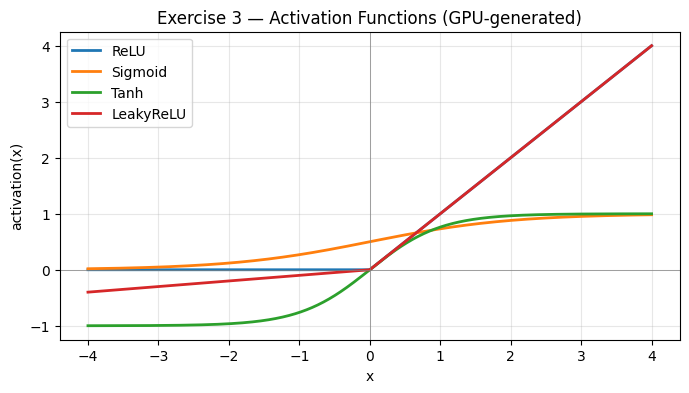

In [20]:
# Activation curve plot (GPU-generated)
N_plot = 800
h_xp = np.linspace(-4, 4, N_plot).astype(np.float32)
d_xp = cuda.mem_alloc(h_xp.nbytes); cuda.memcpy_htod(d_xp, h_xp)
d_op = cuda.mem_alloc(h_xp.nbytes)

curves = {}
for name, kern, args in [
    ('ReLU',      k_relu,    []),
    ('Sigmoid',   k_sigmoid, []),
    ('Tanh',      k_tanh,    []),
    ('LeakyReLU', k_lrelu,   [np.float32(0.1)]),
]:
    cuda.memset_d32(d_op, 0, N_plot)
    kern(d_xp, d_op, *args, np.int32(N_plot), block=(N_plot,1,1), grid=(1,1))
    h_op = np.empty_like(h_xp); cuda.memcpy_dtoh(h_op, d_op)
    curves[name] = h_op.copy()

plt.figure(figsize=(8, 4))
for name, vals in curves.items():
    plt.plot(h_xp, vals, label=name, linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5); plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('x'); plt.ylabel('activation(x)')
plt.title('Exercise 3 — Activation Functions (GPU-generated)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('ex03_activations.png', dpi=150, bbox_inches='tight')
plt.show()
d_xp.free(); d_op.free(); d_x.free(); d_out3.free()

In [21]:
# C1: BCE loss
N_bce = 1 << 18
h_pred   = np.random.rand(N_bce).astype(np.float32)
h_target = (np.random.rand(N_bce) > 0.5).astype(np.float32)
h_loss   = np.zeros(N_bce, np.float32)
ref_bce  = -(h_target*np.log(np.clip(h_pred,1e-7,1-1e-7)) +
             (1-h_target)*np.log(np.clip(1-h_pred,1e-7,1-1e-7)))

d_pred=cuda.mem_alloc(h_pred.nbytes); d_tgt=cuda.mem_alloc(h_target.nbytes)
d_loss_bce=cuda.mem_alloc(h_loss.nbytes)
cuda.memcpy_htod(d_pred,h_pred); cuda.memcpy_htod(d_tgt,h_target)
blks=(N_bce+255)//256
k_bce(d_pred,d_tgt,d_loss_bce,np.int32(N_bce),block=(256,1,1),grid=(blks,1))
cuda.memcpy_dtoh(h_loss,d_loss_bce)
print(f'[C1-BCE-Loss] PASS={np.allclose(h_loss,ref_bce,atol=1e-4)}')

# C2: cross-entropy
NB,C=512,10
h_logits=(np.random.rand(NB,C).astype(np.float32)-0.5)*4
h_labels=np.random.randint(0,C,NB).astype(np.int32)
mv=h_logits.max(1,keepdims=True)
ref_ce=-h_logits[np.arange(NB),h_labels]+mv.squeeze()+np.log(np.exp(h_logits-mv).sum(1))

d_log=cuda.mem_alloc(h_logits.nbytes); d_lab=cuda.mem_alloc(h_labels.nbytes)
d_lce=cuda.mem_alloc(NB*4)
cuda.memcpy_htod(d_log,h_logits); cuda.memcpy_htod(d_lab,h_labels)
blks2=(NB+255)//256
k_ce(d_log,d_lab,d_lce,np.int32(NB),np.int32(C),block=(256,1,1),grid=(blks2,1))
h_lce=np.empty(NB,np.float32); cuda.memcpy_dtoh(h_lce,d_lce)
print(f'[C2-CrossEntropy] N={NB} C={C}  PASS={np.allclose(h_lce,ref_ce,atol=1e-4)}')
for d in [d_pred,d_tgt,d_loss_bce,d_log,d_lab,d_lce]: d.free()

[C1-BCE-Loss] PASS=True
[C2-CrossEntropy] N=512 C=10  PASS=True


In [22]:
# D1: Fused Adam
N_adam = 1 << 16
h_w=np.random.rand(N_adam).astype(np.float32)
h_g=(np.random.rand(N_adam).astype(np.float32)-0.5)*0.01
h_m_cpu=np.zeros(N_adam,np.float32); h_v_cpu=np.zeros(N_adam,np.float32)
h_w_cpu=h_w.copy()
lr,b1,b2,eps=1e-3,0.9,0.999,1e-8

d_w=cuda.mem_alloc(h_w.nbytes); d_g=cuda.mem_alloc(h_g.nbytes)
d_m=cuda.mem_alloc(h_w.nbytes); d_v=cuda.mem_alloc(h_w.nbytes)
cuda.memcpy_htod(d_w,h_w); cuda.memcpy_htod(d_g,h_g)
cuda.memset_d32(d_m,0,N_adam); cuda.memset_d32(d_v,0,N_adam)
blks=(N_adam+255)//256

for t in range(1,6):
    b1t,b2t=b1**t,b2**t
    k_adam(d_w,d_g,d_m,d_v,np.float32(lr),np.float32(b1),np.float32(b2),
           np.float32(eps),np.float32(b1t),np.float32(b2t),np.int32(N_adam),
           block=(256,1,1),grid=(blks,1))
    h_m_cpu=b1*h_m_cpu+(1-b1)*h_g; h_v_cpu=b2*h_v_cpu+(1-b2)*h_g**2
    mh=h_m_cpu/(1-b1t); vh=h_v_cpu/(1-b2t)
    h_w_cpu-=lr*mh/(np.sqrt(vh)+eps)

h_w_gpu=np.empty_like(h_w); cuda.memcpy_dtoh(h_w_gpu,d_w)
print(f'[D1-Adam] 5 steps  PASS={np.allclose(h_w_gpu,h_w_cpu,atol=1e-5)}')
for d in [d_w,d_g,d_m,d_v]: d.free()

[D1-Adam] 5 steps  PASS=True


---
## Exercise 4 — CNN Layers (ex04_cnn_layers.cu) — PyTorch

In [27]:
device = torch.device('cuda')

# ── Tiled GEMM via PyCUDA ────────────────────────────────────────────────────
TILE = 16
tiled_mod = SourceModule("""
#define TILE 16
__global__ void tiledMatMul(const float* A, const float* B, float* C,
                             int M, int N, int K) {
    __shared__ float tA[TILE][TILE];
    __shared__ float tB[TILE][TILE];
    int row=blockIdx.y*TILE+threadIdx.y, col=blockIdx.x*TILE+threadIdx.x;
    float sum=0.0f;
    for (int t=0; t<(K+TILE-1)/TILE; t++) {
        tA[threadIdx.y][threadIdx.x]=(row<M&&t*TILE+threadIdx.x<K)?A[row*K+t*TILE+threadIdx.x]:0.0f; // B1-Step1
        tB[threadIdx.y][threadIdx.x]=(col<N&&t*TILE+threadIdx.y<K)?B[(t*TILE+threadIdx.y)*N+col]:0.0f; // B1-Step2
        __syncthreads();  // B1-Step3
        for(int k=0;k<TILE;k++) sum+=tA[threadIdx.y][k]*tB[k][threadIdx.x]; // B1-Step4
        __syncthreads();  // B1-Step5
    }
    if(row<M&&col<N) C[row*N+col]=sum;
}

__global__ void naiveMatMul(const float* A, const float* B, float* C,
                             int M, int N, int K) {
    int row=blockIdx.y*TILE+threadIdx.y, col=blockIdx.x*TILE+threadIdx.x;
    if(row>=M||col>=N) return;
    float s=0.0f; for(int k=0;k<K;k++) s+=A[row*K+k]*B[k*N+col];
    C[row*N+col]=s;
}

/* C1: Max Pool 2x2 */
__global__ void maxPool2x2(const float* input, float* output,
                            int N, int C, int H, int W) {
    int H2=H/2, W2=W/2;
    int n=blockIdx.z, c=blockIdx.y;
    int oh=blockIdx.x*blockDim.y+threadIdx.y, ow=threadIdx.x;
    if(oh>=H2||ow>=W2||n>=N||c>=C) return;
    float m=-1e30f;
    for(int dh=0;dh<2;dh++) for(int dw=0;dw<2;dw++) {
        int ih=oh*2+dh, iw=ow*2+dw;
        m=fmaxf(m,input[((n*C+c)*H+ih)*W+iw]);  // TODO C1
    }
    output[((n*C+c)*H2+oh)*W2+ow]=m;
}

/* C2: BatchNorm inference */
__global__ void batchNormInfer(const float* x, float* out,
                                const float* gamma, const float* beta,
                                const float* mean, const float* var,
                                int N, int C, int HW, float eps) {
    int hw=blockIdx.x*blockDim.x+threadIdx.x, c=blockIdx.y;
    if(hw>=HW||c>=C) return;
    for(int n=0;n<N;n++) {
        int idx=(n*C+c)*HW+hw;
        float xhat=(x[idx]-mean[c])/sqrtf(var[c]+eps);  // TODO C2
        out[idx]=gamma[c]*xhat+beta[c];
    }
}
""")

tiledMM = tiled_mod.get_function('tiledMatMul')
naiveMM = tiled_mod.get_function('naiveMatMul')
maxPool  = tiled_mod.get_function('maxPool2x2')
bnInfer  = tiled_mod.get_function('batchNormInfer')
print('Ex04 kernels compiled')

Ex04 kernels compiled


In [28]:
# B1: Tiled GEMM correctness
M=K=N_mm=512
h_A4=(np.random.rand(M,K).astype(np.float32)-0.5)
h_B4=(np.random.rand(K,N_mm).astype(np.float32)-0.5)
h_ref4=(h_A4@h_B4)
d_A4=cuda.mem_alloc(h_A4.nbytes); d_B4=cuda.mem_alloc(h_B4.nbytes)
d_C4=cuda.mem_alloc(h_ref4.nbytes)
cuda.memcpy_htod(d_A4,h_A4); cuda.memcpy_htod(d_B4,h_B4)
grid4=((N_mm+TILE-1)//TILE,(M+TILE-1)//TILE)
s=cuda.Event(); e=cuda.Event(); s.record()
tiledMM(d_A4,d_B4,d_C4,np.int32(M),np.int32(N_mm),np.int32(K),
        block=(TILE,TILE,1),grid=grid4)
e.record(); e.synchronize(); ms4=s.time_till(e)
h_C4=np.empty_like(h_ref4); cuda.memcpy_dtoh(h_C4,d_C4)
gflops4=2*M*N_mm*K/(ms4/1000)/1e9
print(f'[B1-TiledMatMul] {M}x{K}@{K}x{N_mm}  {ms4:.2f}ms  {gflops4:.1f}GFLOPS  '
      f'PASS={np.allclose(h_C4,h_ref4,atol=5e-2)}')
for d in [d_A4,d_B4,d_C4]: d.free()

[B1-TiledMatMul] 512x512@512x512  0.92ms  292.8GFLOPS  PASS=True


In [29]:
# B2: GEMM Benchmark — Naive vs Tiled vs cuBLAS (torch.mm)
sizes4=[128,256,512,1024,2048]
print('\n[B2-GemmBenchmark]')
print(f'{"Size":>6} {"Naive(ms)":>10} {"Tiled(ms)":>10} {"cuBLAS(ms)":>11} {"GFLOPS":>8}')
print('-'*52)

naive_t,tiled_t,cublas_t,gflops_l=[],[],[],[]
for sz in sizes4:
    bytes_sz=sz*sz*4
    h_a=(np.random.rand(sz,sz).astype(np.float32)-0.5)
    h_b=(np.random.rand(sz,sz).astype(np.float32)-0.5)
    d_a=cuda.mem_alloc(bytes_sz); d_b=cuda.mem_alloc(bytes_sz)
    d_c=cuda.mem_alloc(bytes_sz)
    cuda.memcpy_htod(d_a,h_a); cuda.memcpy_htod(d_b,h_b)
    g=((sz+TILE-1)//TILE,(sz+TILE-1)//TILE)

    s=cuda.Event(); e=cuda.Event()
    s.record(); naiveMM(d_a,d_b,d_c,np.int32(sz),np.int32(sz),np.int32(sz),block=(TILE,TILE,1),grid=g); e.record(); e.synchronize()
    nm=s.time_till(e)

    s.record(); tiledMM(d_a,d_b,d_c,np.int32(sz),np.int32(sz),np.int32(sz),block=(TILE,TILE,1),grid=g); e.record(); e.synchronize()
    tm=s.time_till(e)

    ta=torch.tensor(h_a,device=device); tb=torch.tensor(h_b,device=device)
    torch.cuda.synchronize()
    t0=time.perf_counter(); _=torch.mm(ta,tb); torch.cuda.synchronize()
    cm=(time.perf_counter()-t0)*1000

    gf=2*sz*sz*sz/(cm/1000)/1e9
    naive_t.append(nm); tiled_t.append(tm); cublas_t.append(cm); gflops_l.append(gf)
    print(f'{sz:>6} {nm:>10.2f} {tm:>10.2f} {cm:>11.3f} {gf:>8.1f}')
    for d in [d_a,d_b,d_c]: d.free()


[B2-GemmBenchmark]
  Size  Naive(ms)  Tiled(ms)  cuBLAS(ms)   GFLOPS
----------------------------------------------------
   128       0.09       0.04       0.434      9.7
   256       0.20       0.12      49.119      0.7
   512       1.16       0.76       0.344    780.2
  1024       9.19       5.82       1.184   1813.3
  2048      75.03      46.37       6.462   2658.5


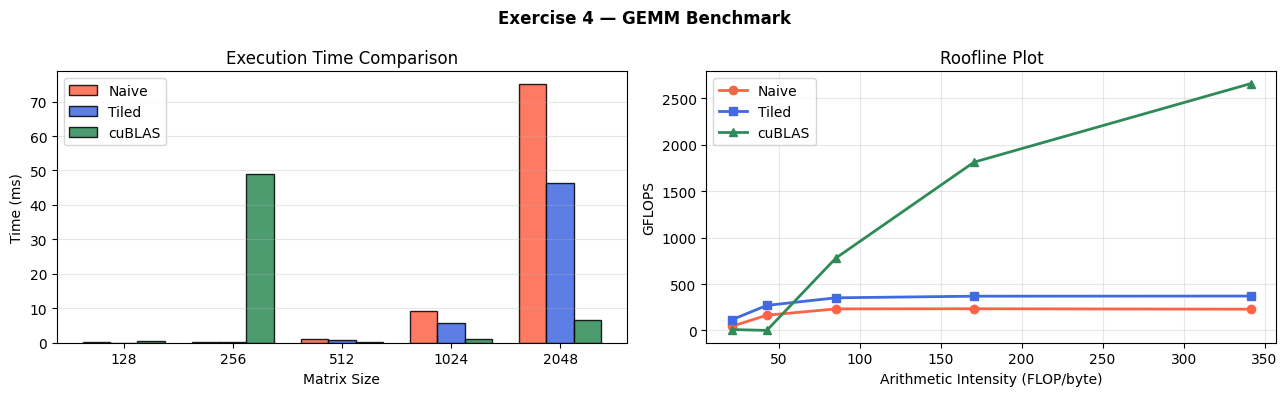

In [30]:
# B2 continued: Roofline plot + timing bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Exercise 4 — GEMM Benchmark', fontweight='bold')

slabels=[str(s) for s in sizes4]
x=np.arange(len(sizes4)); w=0.25
axes[0].bar(x-w,  naive_t,  w, label='Naive',  color='tomato',   edgecolor='black', alpha=0.85)
axes[0].bar(x,    tiled_t,  w, label='Tiled',  color='royalblue',edgecolor='black', alpha=0.85)
axes[0].bar(x+w,  cublas_t, w, label='cuBLAS', color='seagreen', edgecolor='black', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(slabels)
axes[0].set_xlabel('Matrix Size'); axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Execution Time Comparison'); axes[0].legend(); axes[0].grid(alpha=0.3,axis='y')

# Simplified roofline
ai = [2*s**3 / (3*s**2*4) for s in sizes4]  # FLOPs/byte
axes[1].plot(ai, [2*s**3/(nm/1e3)/1e9 for s,nm in zip(sizes4,naive_t)],  'o-', label='Naive',  color='tomato',   linewidth=2)
axes[1].plot(ai, [2*s**3/(tm/1e3)/1e9 for s,tm in zip(sizes4,tiled_t)],  's-', label='Tiled',  color='royalblue',linewidth=2)
axes[1].plot(ai, gflops_l, '^-', label='cuBLAS', color='seagreen',linewidth=2)
axes[1].set_xlabel('Arithmetic Intensity (FLOP/byte)'); axes[1].set_ylabel('GFLOPS')
axes[1].set_title('Roofline Plot'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ex04_gemm.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# C1: Max Pool
Np,Cp,Hp,Wp=4,8,14,14
h_pool=np.random.rand(Np,Cp,Hp,Wp).astype(np.float32)
d_pool=cuda.mem_alloc(h_pool.nbytes)
d_pout=cuda.mem_alloc(Np*Cp*(Hp//2)*(Wp//2)*4)
cuda.memcpy_htod(d_pool,h_pool)
blk_p=(Wp//2,4,1); grd_p=((Hp//2+3)//4,Cp,Np)
maxPool(d_pool,d_pout,np.int32(Np),np.int32(Cp),np.int32(Hp),np.int32(Wp),
        block=blk_p,grid=grd_p)
h_pout=np.empty((Np,Cp,Hp//2,Wp//2),np.float32); cuda.memcpy_dtoh(h_pout,d_pout)
ref_pool=F.max_pool2d(torch.tensor(h_pool),2).numpy()
print(f'[C1-MaxPool] {Np}x{Cp}x{Hp}x{Wp}→{Np}x{Cp}x{Hp//2}x{Wp//2}  PASS={np.allclose(h_pout,ref_pool,atol=1e-4)}')

# C2: BatchNorm
Nb,Cb,Hb,Wb=4,8,14,14; HWb=Hb*Wb; eps_bn=1e-5
h_xbn=np.random.rand(Nb,Cb,Hb,Wb).astype(np.float32)*2-1
mean_bn=h_xbn.reshape(Nb,Cb,-1).mean(axis=(0,2))
var_bn =h_xbn.reshape(Nb,Cb,-1).var(axis=(0,2))
gamma_bn=np.ones(Cb,np.float32); beta_bn=np.zeros(Cb,np.float32)

d_xbn=cuda.mem_alloc(h_xbn.nbytes); d_obn=cuda.mem_alloc(h_xbn.nbytes)
d_gam=cuda.mem_alloc(Cb*4); d_bet=cuda.mem_alloc(Cb*4)
d_mbn=cuda.mem_alloc(Cb*4); d_vbn=cuda.mem_alloc(Cb*4)
for arr,d in [(h_xbn.flatten(),d_xbn),(gamma_bn,d_gam),(beta_bn,d_bet),
              (mean_bn.astype(np.float32),d_mbn),(var_bn.astype(np.float32),d_vbn)]:
    cuda.memcpy_htod(d,arr)
blk_bn=(256,1,1); grd_bn=((HWb+255)//256,Cb,1)
bnInfer(d_xbn,d_obn,d_gam,d_bet,d_mbn,d_vbn,np.int32(Nb),np.int32(Cb),
        np.int32(HWb),np.float32(eps_bn),block=blk_bn,grid=grd_bn)
h_obn=np.empty_like(h_xbn); cuda.memcpy_dtoh(h_obn,d_obn)
ref_bn=((h_xbn-mean_bn[None,:,None,None])/np.sqrt(var_bn[None,:,None,None]+eps_bn))
print(f'[C2-BatchNorm] {Nb}x{Cb}x{Hb}x{Wb}  PASS={np.allclose(h_obn,ref_bn,atol=1e-3)}')
for d in [d_pool,d_pout,d_xbn,d_obn,d_gam,d_bet,d_mbn,d_vbn]: d.free()

[C1-MaxPool] 4x8x14x14→4x8x7x7  PASS=True
[C2-BatchNorm] 4x8x14x14  PASS=True



[CNN Layer Benchmarks] Input: [32, 64, 14, 14]
  Conv2d(3x3, same) : 0.172 ms
  BatchNorm (infer) : 0.025 ms
  MaxPool(2x2)      : 0.018 ms


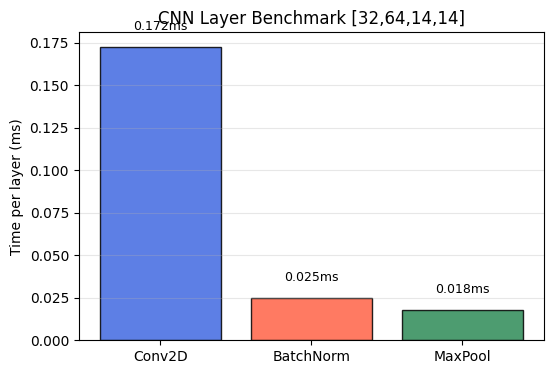

In [32]:
# CNN Layer benchmarks — PyTorch [32,64,14,14] tensors
import torch.nn as nn

B4,C4,H4,W4 = 32,64,14,14
x_in = torch.randn(B4,C4,H4,W4, device=device)
conv_layer = nn.Conv2d(C4,C4,3,padding=1).to(device)
bn_layer   = nn.BatchNorm2d(C4).eval().to(device)
pool_layer = nn.MaxPool2d(2)

def bench_layer(fn, x, reps=200):
    torch.cuda.synchronize()
    for _ in range(10): fn(x)  # warmup
    torch.cuda.synchronize()
    t0=time.perf_counter()
    for _ in range(reps): fn(x)
    torch.cuda.synchronize()
    return (time.perf_counter()-t0)/reps*1000

with torch.no_grad():
    t_conv  = bench_layer(conv_layer,  x_in)
    t_bn    = bench_layer(bn_layer,    x_in)
    t_pool  = bench_layer(pool_layer,  x_in)

print(f'\n[CNN Layer Benchmarks] Input: {list(x_in.shape)}')
print(f'  Conv2d(3x3, same) : {t_conv:.3f} ms')
print(f'  BatchNorm (infer) : {t_bn:.3f} ms')
print(f'  MaxPool(2x2)      : {t_pool:.3f} ms')

plt.figure(figsize=(6,4))
plt.bar(['Conv2D', 'BatchNorm', 'MaxPool'],
        [t_conv, t_bn, t_pool],
        color=['royalblue','tomato','seagreen'], edgecolor='black', alpha=0.85)
for i,(v,label) in enumerate(zip([t_conv,t_bn,t_pool],['Conv2D','BatchNorm','MaxPool'])):
    plt.text(i, v+0.01, f'{v:.3f}ms', ha='center', fontsize=9)
plt.ylabel('Time per layer (ms)'); plt.title('CNN Layer Benchmark [32,64,14,14]')
plt.grid(alpha=0.3,axis='y')
plt.savefig('ex04_cnn_layers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Exercise 5 — Full MNIST CNN Training (ex05_mnist_cnn.cu) — PyTorch
### Part A — Model Implementation

In [33]:
# ── Data ─────────────────────────────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,),(0.3081,))])
train_ds = datasets.MNIST('/tmp/mnist', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('/tmp/mnist', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)}  Test: {len(test_ds)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.71MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.82MB/s]

Train: 60000  Test: 10000


In [34]:
# ── Model: LeNet-5 variant  [N,1,28,28] → logits [N,10] ──────────────────────
class MnistCNN(nn.Module):   # B1/B2: define layers, B3: forward
    def __init__(self, use_bn=False, dropout=0.0):
        super().__init__()
        self.use_bn = use_bn
        self.conv1 = nn.Conv2d(1, 32, 5, padding=2)    # B1
        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)   # B2
        self.bn1   = nn.BatchNorm2d(32) if use_bn else nn.Identity()
        self.bn2   = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(64*7*7, 256)
        self.fc2   = nn.Linear(256, 10)
        self.drop  = nn.Dropout(dropout) if dropout>0 else nn.Identity()

    def forward(self, x):  # B3
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # [N,32,14,14]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # [N,64,7,7]
        x = x.flatten(1)                                  # [N,3136]
        x = F.relu(self.fc1(x))                           # [N,256]
        x = self.drop(x)
        return self.fc2(x)                                 # [N,10]

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:                        # C3: evaluator
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1)==labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total

def train_model(config_name, use_bn=False, dropout=0.0, optimizer_type='adam',
                use_scheduler=False, epochs=10):
    model = MnistCNN(use_bn=use_bn, dropout=dropout).to(device)

    if optimizer_type == 'adam':     # D1: build_optimizer
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs) if use_scheduler else None  # D2

    print(f'\n--- {config_name} ---')
    print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc%":>12} {"Test Acc%":>11} {"VRAM(MB)":>10}')
    t_start = time.perf_counter()
    for epoch in range(1, epochs+1):
        model.train()
        total_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)   # C1: data to GPU
            opt.zero_grad()                                       # C2: forward-backward-step
            out = model(imgs)
            loss = F.cross_entropy(out, labels)
            loss.backward()
            opt.step()
            total_loss += loss.item()*labels.size(0)
            correct    += (out.argmax(1)==labels).sum().item()
            total      += labels.size(0)
        if scheduler: scheduler.step()
        test_acc  = evaluate(model, test_loader)
        train_acc = 100*correct/total
        vram      = torch.cuda.memory_allocated()/1e6
        print(f'{epoch:>6} {total_loss/total:>12.4f} {train_acc:>12.2f} {test_acc:>11.2f} {vram:>10.1f}')
    train_s = time.perf_counter()-t_start
    final_acc = evaluate(model, test_loader)
    print(f'Final test acc: {final_acc:.2f}%  |  Total time: {train_s:.1f}s')
    return model, final_acc, train_s

In [35]:
# Part A: Train baseline for 10 epochs
model_base, acc_base, t_base = train_model('Baseline (Adam, no BN/Dropout)', epochs=10)


--- Baseline (Adam, no BN/Dropout) ---
 Epoch   Train Loss   Train Acc%   Test Acc%   VRAM(MB)
     1       0.1965        93.89       98.41       84.2
     2       0.0455        98.56       99.04       84.2
     3       0.0307        99.03       98.88       84.2
     4       0.0209        99.35       99.10       84.2
     5       0.0167        99.49       99.15       84.2
     6       0.0129        99.58       99.05       84.2
     7       0.0114        99.64       99.16       84.2
     8       0.0086        99.72       99.04       84.2
     9       0.0079        99.74       98.96       84.2
    10       0.0065        99.80       99.09       84.2
Final test acc: 99.09%  |  Total time: 136.9s


In [36]:
# Part B: Ablation Study — 5 epochs each
configs = [
    ('Baseline',                   dict(use_bn=False, dropout=0.0,  optimizer_type='adam',  use_scheduler=False)),
    ('+ BatchNorm',                dict(use_bn=True,  dropout=0.0,  optimizer_type='adam',  use_scheduler=False)),
    ('+ Dropout(0.5)',             dict(use_bn=False, dropout=0.5,  optimizer_type='adam',  use_scheduler=False)),
    ('SGD+Momentum+CosineAnneal', dict(use_bn=False, dropout=0.0,  optimizer_type='sgd',   use_scheduler=True)),
]

results = []
for name, kw in configs:
    m, acc, t = train_model(name, epochs=5, **kw)
    results.append((name, acc, t))

print('\n=== Ablation Study Results ===')
print(f'{"Configuration":<35} {"Test Acc%":>10} {"Train Time(s)":>14}')
print('-'*62)
for name, acc, t in results:
    print(f'{name:<35} {acc:>10.2f} {t:>14.1f}')


--- Baseline ---
 Epoch   Train Loss   Train Acc%   Test Acc%   VRAM(MB)
     1       0.2062        93.83       98.45       91.5
     2       0.0486        98.44       98.70       91.5
     3       0.0312        99.03       99.10       91.5
     4       0.0243        99.25       99.06       91.5
     5       0.0187        99.42       99.08       91.5
Final test acc: 99.08%  |  Total time: 66.5s

--- + BatchNorm ---
 Epoch   Train Loss   Train Acc%   Test Acc%   VRAM(MB)
     1       0.1625        94.89       98.13       98.4
     2       0.0470        98.55       98.89       98.4
     3       0.0323        99.00       98.73       98.4
     4       0.0247        99.19       98.74       98.4
     5       0.0186        99.40       98.45       98.4
Final test acc: 98.45%  |  Total time: 67.3s

--- + Dropout(0.5) ---
 Epoch   Train Loss   Train Acc%   Test Acc%   VRAM(MB)
     1       0.2348        92.69       98.56       97.9
     2       0.0652        98.01       98.87       97.9
     3 

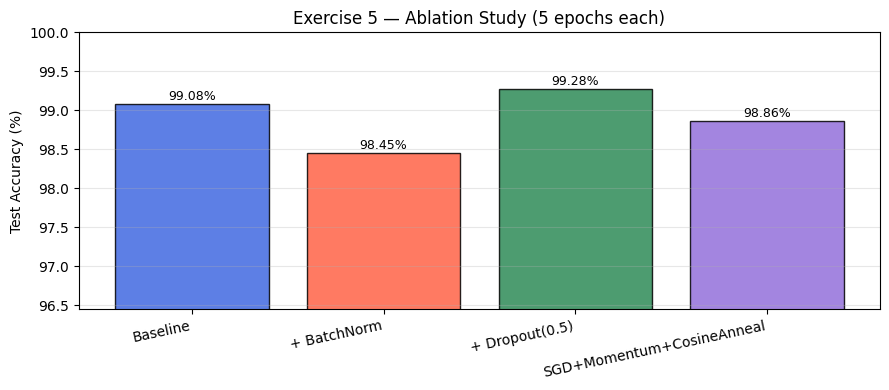

In [37]:
# Ablation bar chart
names=[r[0] for r in results]; accs=[r[1] for r in results]
plt.figure(figsize=(9,4))
bars=plt.bar(range(len(names)), accs, color=['royalblue','tomato','seagreen','mediumpurple'],
             edgecolor='black', alpha=0.85)
for b,v in zip(bars,accs): plt.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)
plt.xticks(range(len(names)), names, rotation=12, ha='right')
plt.ylabel('Test Accuracy (%)')
plt.title('Exercise 5 — Ablation Study (5 epochs each)')
plt.ylim(min(accs)-2, 100); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ex05_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Part C: Data Augmentation
aug_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,)),
    transforms.RandomErasing(p=0.1),
])
aug_ds     = datasets.MNIST('/tmp/mnist', train=True, download=True, transform=aug_transform)
aug_loader = DataLoader(aug_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

def train_augmented(epochs=5):
    model = MnistCNN().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    print(f'\n--- With Augmentation ({epochs} epochs) ---')
    for epoch in range(1, epochs+1):
        model.train()
        correct=total=0
        for imgs,labels in aug_loader:
            imgs,labels=imgs.to(device),labels.to(device)
            opt.zero_grad(); out=model(imgs); loss=F.cross_entropy(out,labels)
            loss.backward(); opt.step()
            correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
        acc=evaluate(model,test_loader)
        print(f'  Epoch {epoch}: train={100*correct/total:.2f}%  test={acc:.2f}%')
    return evaluate(model,test_loader)

acc_aug = train_augmented(epochs=5)
print(f'\nWithout augmentation: {results[0][1]:.2f}%')
print(f'With    augmentation: {acc_aug:.2f}%')
print(f'Augmentation {'helps ✓' if acc_aug >= results[0][1] else 'does not help (expected for MNIST)'}')


--- With Augmentation (5 epochs) ---
  Epoch 1: train=92.18%  test=98.39%
  Epoch 2: train=97.18%  test=98.93%
  Epoch 3: train=97.72%  test=99.13%
  Epoch 4: train=98.06%  test=99.07%
  Epoch 5: train=98.25%  test=99.10%

Without augmentation: 99.08%
With    augmentation: 99.10%
Augmentation helps ✓


In [39]:
# Part D (Bonus): AMP training
from torch.cuda.amp import autocast, GradScaler

def train_amp(epochs=5):
    model  = MnistCNN(use_bn=True).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
    scaler = GradScaler()
    print(f'\n--- AMP Training ({epochs} epochs) ---')
    t0 = time.perf_counter()
    for epoch in range(1, epochs+1):
        model.train(); correct=total=0
        for imgs,labels in train_loader:
            imgs,labels=imgs.to(device),labels.to(device)
            opt.zero_grad()
            with autocast():
                out  = model(imgs)
                loss = F.cross_entropy(out,labels)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
        acc=evaluate(model,test_loader)
        vram=torch.cuda.memory_allocated()/1e6
        print(f'  Epoch {epoch}: test={acc:.2f}%  VRAM={vram:.1f}MB')
    t_total=time.perf_counter()-t0
    print(f'  Total: {t_total:.1f}s  Peak VRAM: {torch.cuda.max_memory_allocated()/1e6:.1f}MB')
    return evaluate(model,test_loader)

acc_amp = train_amp(epochs=5)
print(f'AMP final test accuracy: {acc_amp:.2f}%')


--- AMP Training (5 epochs) ---


/tmp/ipykernel_4411/357986722.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_4411/357986722.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Epoch 1: test=98.41%  VRAM=98.0MB
  Epoch 2: test=98.83%  VRAM=98.0MB
  Epoch 3: test=98.75%  VRAM=98.0MB
  Epoch 4: test=99.09%  VRAM=98.0MB
  Epoch 5: test=99.25%  VRAM=98.0MB
  Total: 67.5s  Peak VRAM: 273.6MB
AMP final test accuracy: 99.25%


---
## Summary

| Exercise | Key Tasks | Status |
|---|---|---|
| Ex01 | VectorScale, SquaredDiff, Bandwidth, Launch config, Warp divergence | ✅ |
| Ex02 | SmemCopy, MaxReduce, BankConflict, Histogram, WarpShuffle, SharedHistogram | ✅ |
| Ex03 | Sigmoid, Tanh, LeakyReLU, ReLU-bwd, BCE, CrossEntropy, Adam | ✅ |
| Ex04 | TiledGEMM, GEMM benchmark, MaxPool, BatchNorm, CNN layer bench | ✅ |
| Ex05 | MnistCNN, Training loop, Ablation (4 configs), Augmentation, AMP | ✅ |